# 第7章 异方差

## 7.5 处理异方差的 Stata 命令及实例

### 1. 画残差图

nerlove.dta数据集包括以下变量：tc(总成本)，q(总产量)，pl(工资率)，pk(资本的使用成本)与pf(燃料价格)，以及相应的对数值。

In [1]:
use data/nerlove.dta,clear
reg lntc lnq lnpl lnpk lnpf

(Nerlove 1963 paper)

      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(4, 140)       =    437.90
       Model |  269.524728         4  67.3811819   Prob > F        =    0.0000
    Residual |  21.5420958       140  .153872113   R-squared       =    0.9260
-------------+----------------------------------   Adj R-squared   =    0.9239
       Total |  291.066823       144  2.02129738   Root MSE        =    .39227

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .7209135   .0174337    41.35   0.000     .6864462    .7553808
        lnpl |   .4559645    .299802     1.52   0.131    -.1367602    1.048689
        lnpk |  -.2151476   .3398295    -0.63   0.528    -.8870089    .4567136
        lnpf |   .4258137   .

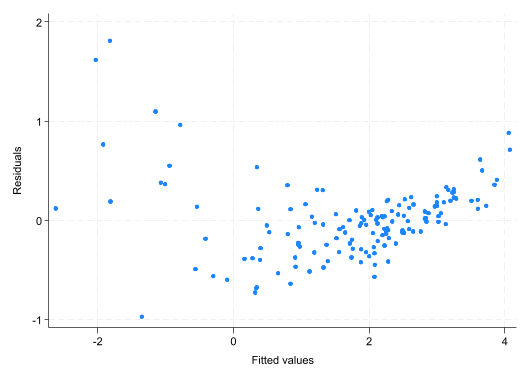

In [2]:
* 为初步考察是否存在异方差，下面画残差与拟合值的散点图
rvfplot

从图中可大致看出，当总成本对数(lntc的拟合值)较小时，扰动项的方差较大。

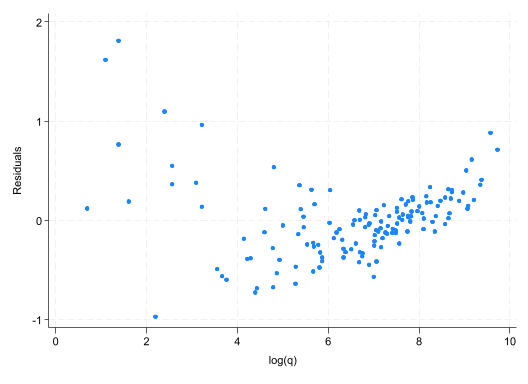

In [3]:
* 进一步考察残差与解释变量lnq的散点图
rvpplot lnq

当总产量对数(lnq)越小时，扰动项的方差越大。以上两图的大致轮廓基本一致，表明很可能存在异方差，即扰动项的方差随着观测值而变。

### 2. BP检验

```
estat hettest,iid rhs
```

- estat指post-estimation statistics(估计后统计量)，即在完成估计后所计算的后续统计量。
- hettest表示heteroskedasticity test。
- 选择项iid表示仅假定数据为iid，而无须正态假定。
- 选择项rhs表示，使用方程右边的全部解释变量进行辅助回归，默认使用拟合值$\hat y$进行辅助回归。

In [4]:
* quietly表示执行此命令，但不在Stata的结果窗口显示运行结果
quietly reg lntc lnq lnpl lnpk lnpf
* 使用拟合值进行BP检验
estat hettest, iid


Breusch–Pagan/Cook–Weisberg test for heteroskedasticity 
Assumption: i.i.d. error terms
Variable: Fitted values of lntc

H0: Constant variance

    chi2(1) =  29.13
Prob > chi2 = 0.0000


In [5]:
* 其次，使用所有解释变量进行BP检验
estat hettest, iid rhs


Breusch–Pagan/Cook–Weisberg test for heteroskedasticity 
Assumption: i.i.d. error terms
Variables: All independent variables

H0: Constant variance

    chi2(4) =  36.16
Prob > chi2 = 0.0000


In [6]:
* 最后，使用变量lnq进行BP检验
estat hettest lnq,iid


Breusch–Pagan/Cook–Weisberg test for heteroskedasticity 
Assumption: i.i.d. error terms
Variable: lnq

H0: Constant variance

    chi2(1) =  32.10
Prob > chi2 = 0.0000


以上各种形式BP检验的p值都等于0.0000，故强烈拒绝同方差的原假设，认为存在异方差。

### 3.怀特检验

```
estat imtest,white
```

- imtest指information matrix test(信息矩阵检验)

In [7]:
estat imtest,white


White's test
H0: Homoskedasticity
Ha: Unrestricted heteroskedasticity

   chi2(14) =  73.88
Prob > chi2 = 0.0000

Cameron & Trivedi's decomposition of IM-test

--------------------------------------------------
              Source |       chi2     df         p
---------------------+----------------------------
  Heteroskedasticity |      73.88     14    0.0000
            Skewness |      22.79      4    0.0001
            Kurtosis |       2.62      1    0.1055
---------------------+----------------------------
               Total |      99.29     19    0.0000
--------------------------------------------------


检验结果显示，p值(Prob>chi2)等于0.0000，故强烈拒绝同方差的原假设，认为存在异方差。

### 4. WLS

在得到扰动项方差的估计值$\{\hat\sigma_i^2\}_{i=1}^n$后，可作为权重进行WLS估计。假设已把$\{\hat\sigma_i^2\}_{i=1}^n$存储在变量var上，则可通过如下Stata命令来实现WLS：

```
reg y x1 x2 x3[aw=1/var]
```

- aw表示analytical weight，为扰动项方差(而不是标准差)的倒数。

In [8]:
* 首先计算残差，并记为e1:
quietly reg lntc lnq lnpl lnpk lnpf
predict e1,residual
* 其次，生成残差的平方，并记为e2:
gen e2=e1^2
* 将残差平方取对数
gen lne2=log(e2)
* 假设lne2为变量lnq的线性函数，进行以下辅助回归：
reg lne2 lnq


      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(1, 143)       =     21.54
       Model |  105.722127         1  105.722127   Prob > F        =    0.0000
    Residual |  701.999749       143  4.90908916   R-squared       =    0.1309
-------------+----------------------------------   Adj R-squared   =    0.1248
       Total |  807.721876       144  5.60917969   Root MSE        =    2.2156

------------------------------------------------------------------------------
        lne2 | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |  -.4479545   .0965276    -4.64   0.000    -.6387597   -.2571492
       _cons |  -.7452062   .6591018    -1.13   0.260    -2.048048    .5576351
------------------------------------------------------------------------------


从上表可知，尽管变量lnq在1%平上显著，但$R^2$仅为0.1309，而且常数项不显著(p值为0.260)。因此，下面去掉常数项，重新进行辅助回归。

In [9]:
reg lne2 lnq,noc


      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(1, 144)       =    419.95
       Model |  2065.53636         1  2065.53636   Prob > F        =    0.0000
    Residual |  708.275258       144  4.91857818   R-squared       =    0.7447
-------------+----------------------------------   Adj R-squared   =    0.7429
       Total |  2773.81162       145  19.1297353   Root MSE        =    2.2178

------------------------------------------------------------------------------
        lne2 | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |  -.5527533   .0269733   -20.49   0.000    -.6060681   -.4994384
------------------------------------------------------------------------------


上表显示，$R^2$上升为0.7447，即解释变量lnq可以解释lne2近75%变动，残差平方的变动与lnq高度相关。

In [10]:
* 接着计算以上辅助回归的拟合值，并记为lne2f:
predict lne2f
* 去掉对数后，即得到方差的估计值，并记为e2f:
gen e2f=exp(lne2f)
* 最后，使用方差估计值的倒数作为权重，进行 WLS 回归：
reg lntc lnq lnpl lnpk lnpf [aw=1/e2f]

(option xb assumed; fitted values)
(sum of wgt is 8,181.07969295173)

      Source |       SS           df       MS      Number of obs   =       145
-------------+----------------------------------   F(4, 140)       =    895.03
       Model |  173.069988         4  43.2674971   Prob > F        =    0.0000
    Residual |  6.76790874       140  .048342205   R-squared       =    0.9624
-------------+----------------------------------   Adj R-squared   =    0.9613
       Total |  179.837897       144  1.24887428   Root MSE        =    .21987

------------------------------------------------------------------------------
        lntc | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .8759035   .0153841    56.94   0.000     .8454883    .9063187
        lnpl |   .5603879   .1734141     3.23   0.002     .2175389    .9032369
        lnpk |  -.0929807   .1960402    -0.47   0.636    -.4

- WLS回归的结果显示，lnpk的系数估计值由“-0.22”(OLS 估计值)改进为“-0.09”(其理论值应为正数)。
- 另一方面，使用OLS时，变量lnpl的p值为0.13，在10%水平上不显著；而使用WLS后，该变量的p值变为0.002，在1%水平上显著不为0。
- 由此可知，由于Nerlove(1963)数据存在明显的异方差，使用WLS后提高了估计效率。

In [11]:
* 如果担心对条件方差函数的设定不准确，导致加权变换后的新扰动项仍有一定的异方差，可使用稳健标准误进行WLS估计：
reg lntc lnq lnpl lnpk lnpf [aw=1/e2f],r

(sum of wgt is 8,181.07969295173)

Linear regression                               Number of obs     =        145
                                                F(4, 140)         =     534.50
                                                Prob > F          =     0.0000
                                                R-squared         =     0.9624
                                                Root MSE          =     .21987

------------------------------------------------------------------------------
             |               Robust
        lntc | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lnq |   .8759035    .020787    42.14   0.000     .8348064    .9170006
        lnpl |   .5603879   .2090099     2.68   0.008      .147164    .9736118
        lnpk |  -.0929807   .3016444    -0.31   0.758    -.6893478    .5033864
        lnpf |   .4672438   .0439915    10.62   0.000     .

从上表可知，无论是否使用稳健标准误，WLS的回归系数都相同，但标准误有所不同。